Cell1 — Configuration

In [1]:
# =========================================================
# PLANTES
# 07_machine_learning_hog_maladies_balanced.ipynb
#
# Objectif :
#   Classification des MALADIES avec descripteurs HOG
#   et rééquilibrage des classes (class_weight='balanced').
#
# Rôle dans l'étude d'ablation :
#   HOG + balanced — mesurer l'apport conjoint de HOG
#   et du rééquilibrage par rapport au baseline pixels bruts.
# =========================================================

import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import gc
import json

from pathlib import Path
from tqdm import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
from skimage.feature import hog as sk_hog

import joblib

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# Chemins
# ---------------------------------------------------------
ROOT_DIR  = Path(r"C:\Users\Bronislaw\DS\Arena\MALADIES")
BASE_DIR  = ROOT_DIR / "all"
SPLIT_DIR = BASE_DIR / "new_splits"
OUT_DIR   = ROOT_DIR / "new_ml_outputs_hog_balanced"

OUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_CSV = SPLIT_DIR / "train.csv"
VAL_CSV   = SPLIT_DIR / "val.csv"
TEST_CSV  = SPLIT_DIR / "test.csv"

# ---------------------------------------------------------
# Paramètres généraux
# ---------------------------------------------------------
RANDOM_STATE = 42
IMG_SIZE     = 64
BATCH_SIZE   = 512
N_EPOCHS     = 5

MAX_IMAGES_TRAIN = None
MAX_IMAGES_VAL   = None
MAX_IMAGES_TEST  = None

# ---------------------------------------------------------
# Paramètres HOG
# ---------------------------------------------------------
HOG_ORIENTATIONS    = 9
HOG_PIXELS_PER_CELL = (16, 16)
HOG_CELLS_PER_BLOCK = (1, 1)
HOG_BLOCK_NORM      = "L2-Hys"
HOG_TRANSFORM_SQRT  = True

n_cells_h = IMG_SIZE // HOG_PIXELS_PER_CELL[0]
n_cells_w = IMG_SIZE // HOG_PIXELS_PER_CELL[1]
n_blocks_h = n_cells_h - HOG_CELLS_PER_BLOCK[0] + 1
n_blocks_w = n_cells_w - HOG_CELLS_PER_BLOCK[1] + 1

N_HOG_FEATURES = (
    n_blocks_h * n_blocks_w *
    HOG_CELLS_PER_BLOCK[0] * HOG_CELLS_PER_BLOCK[1] *
    HOG_ORIENTATIONS
)

# ---------------------------------------------------------
# Références pour comparaison
# ---------------------------------------------------------
REF_NB06_ACC = None
REF_NB06_F1M = None
REF_NB06_F1W = None

REF_NB06BIS_ACC = None
REF_NB06BIS_F1M = None
REF_NB06BIS_F1W = None

print("✅ Configuration chargée.")
print("OUT_DIR        :", OUT_DIR)
print("N_EPOCHS       :", N_EPOCHS)
print("N_HOG_FEATURES :", N_HOG_FEATURES)
print()
print("Fichiers splits :")
print(" -", TRAIN_CSV, "| exists =", TRAIN_CSV.exists())
print(" -", VAL_CSV,   "| exists =", VAL_CSV.exists())
print(" -", TEST_CSV,  "| exists =", TEST_CSV.exists())

✅ Configuration chargée.
OUT_DIR        : C:\Users\Bronislaw\DS\Arena\MALADIES\new_ml_outputs_hog_balanced
N_EPOCHS       : 5
N_HOG_FEATURES : 144

Fichiers splits :
 - C:\Users\Bronislaw\DS\Arena\MALADIES\all\new_splits\train.csv | exists = True
 - C:\Users\Bronislaw\DS\Arena\MALADIES\all\new_splits\val.csv | exists = True
 - C:\Users\Bronislaw\DS\Arena\MALADIES\all\new_splits\test.csv | exists = True


Cell2 — Fonctions utilitaires

In [2]:
def normalize_columns(df):
    df = df.copy()
    df.columns = df.columns.astype(str).str.strip()
    return df


def detect_columns(df, task="maladies"):
    df = normalize_columns(df)

    path_candidates = [
        "chemin", "target_path", "path",
        "image_path", "filepath", "file_path", "img_path"
    ]

    if task == "maladies":
        label_candidates = [
            "maladie_label", "maladie_class",
            "disease_label", "disease_class",
            "label", "class", "target",
            "maladie", "disease"
        ]
    else:
        label_candidates = [
            "taxon_label", "taxon_class",
            "label", "class", "target", "taxon"
        ]

    path_col = next((c for c in path_candidates if c in df.columns), None)
    label_col = next((c for c in label_candidates if c in df.columns), None)

    if path_col is None:
        raise ValueError("Aucune colonne chemin trouvée. Colonnes : " + str(df.columns.tolist()))
    if label_col is None:
        raise ValueError("Aucune colonne label trouvée. Colonnes : " + str(df.columns.tolist()))

    return path_col, label_col


def infer_schema_from_csv(csv_path, task="maladies"):
    df_tmp = pd.read_csv(csv_path, sep=None, engine="python", encoding="utf-8-sig", nrows=5)
    df_tmp = normalize_columns(df_tmp)
    return detect_columns(df_tmp, task=task)


def resolve_image_path_robust(raw_path, base_dir=None):
    raw_path = str(raw_path).strip().replace("\\", "/")
    p = Path(raw_path)
    if p.exists():
        return p
    if base_dir is not None:
        parts = [x for x in raw_path.split("/") if x]
        if len(parts) >= 2:
            return Path(base_dir) / parts[-2] / parts[-1]
    return p


def iter_hog_batches_from_df(df, split_name, img_size=64,
                              batch_size=512, base_dir=None,
                              task="maladies", debug_missing=5):
    """
    Générateur streaming HOG à partir d'un DataFrame (pour shuffle par époque).
    """
    df = normalize_columns(df)
    path_col, label_col = detect_columns(df, task=task)

    X_buf, y_buf = [], []
    n_seen = 0
    n_ok = 0
    n_missing = 0
    n_unreadable = 0
    n_hog_errors = 0
    missing_examples = []

    print(f"\nStreaming HOG {split_name} ...")
    print("  path_col   :", path_col)
    print("  label_col  :", label_col)
    print("  batch_size :", batch_size)
    print("  img_size   :", img_size)

    for _, row in df.iterrows():
        n_seen += 1
        img_path = resolve_image_path_robust(row[path_col], base_dir)

        if not img_path.exists():
            n_missing += 1
            if len(missing_examples) < debug_missing:
                missing_examples.append({
                    "csv": str(row[path_col]),
                    "resolved": str(img_path)
                })
            continue

        gray = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if gray is None:
            n_unreadable += 1
            continue

        try:
            gray = cv2.resize(gray, (img_size, img_size))
            features = sk_hog(
                gray,
                orientations=HOG_ORIENTATIONS,
                pixels_per_cell=HOG_PIXELS_PER_CELL,
                cells_per_block=HOG_CELLS_PER_BLOCK,
                block_norm=HOG_BLOCK_NORM,
                transform_sqrt=HOG_TRANSFORM_SQRT,
                feature_vector=True
            )
            X_buf.append(features.astype(np.float32))
            y_buf.append(str(row[label_col]))
            n_ok += 1
        except Exception:
            n_hog_errors += 1
            continue

        if len(X_buf) >= batch_size:
            yield np.asarray(X_buf, dtype=np.float32), np.asarray(y_buf)
            X_buf.clear()
            y_buf.clear()
            gc.collect()

    if len(X_buf) > 0:
        yield np.asarray(X_buf, dtype=np.float32), np.asarray(y_buf)

    print(f"✅ Fin streaming HOG {split_name}")
    print(f"   images valides : {n_ok:,} | manquantes : {n_missing:,} | erreurs HOG : {n_hog_errors:,}")

    if missing_examples:
        print("\nExemples manquants :")
        for ex in missing_examples:
            print("  -", ex["csv"])
            print("   ", ex["resolved"])


def get_train_classes_and_weights(csv_path, max_images=None, task="maladies"):
    _, label_col = infer_schema_from_csv(csv_path, task=task)
    df_lab = pd.read_csv(csv_path, usecols=[label_col], sep=None, engine="python", encoding="utf-8-sig")
    df_lab = normalize_columns(df_lab)
    y = df_lab[label_col].astype(str)
    if max_images is not None:
        y = y.iloc[:max_images]
    classes = np.array(sorted(y.unique()))
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)
    class_weight_dict = {cls: float(w) for cls, w in zip(classes, weights)}
    return classes, class_weight_dict


def get_train_classes(csv_path, max_images=None, task="maladies"):
    _, label_col = infer_schema_from_csv(csv_path, task=task)
    df_lab = pd.read_csv(csv_path, usecols=[label_col], sep=None, engine="python", encoding="utf-8-sig")
    df_lab = normalize_columns(df_lab)
    y = df_lab[label_col].astype(str)
    if max_images is not None:
        y = y.iloc[:max_images]
    return np.array(sorted(y.unique()))


def compute_metrics(y_true, y_pred, split_name):
    return {
        "split": split_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0)
    }


def predict_stream_hog(csv_path, split_name, scaler, clf,
                        img_size=64, batch_size=512,
                        base_dir=None, max_images=None,
                        task="maladies"):
    # Prédiction par streaming HOG (lecture directe CSV, pas de shuffle)
    path_col, label_col = infer_schema_from_csv(csv_path, task=task)
    reader = pd.read_csv(csv_path, sep=None, engine="python", encoding="utf-8-sig")
    reader = normalize_columns(reader)
    if max_images is not None:
        reader = reader.iloc[:max_images]

    y_true_all = []
    y_pred_all = []

    for X_batch, y_batch in iter_hog_batches_from_df(
        reader,
        split_name=split_name,
        img_size=img_size,
        batch_size=batch_size,
        base_dir=base_dir,
        task=task
    ):
        X_scaled = scaler.transform(X_batch)
        y_pred = clf.predict(X_scaled)
        y_true_all.extend(y_batch.tolist())
        y_pred_all.extend(y_pred.tolist())
        del X_batch, X_scaled, y_batch, y_pred
        gc.collect()

    return np.array(y_true_all), np.array(y_pred_all)


print("✅ Fonctions utilitaires définies.")

✅ Fonctions utilitaires définies.


Cell3 — Vérification des splits

In [3]:
print("=" * 60)
print("VÉRIFICATION DES SPLITS MALADIES")
print("=" * 60)

all_ok = True
for split_name, csv_path in [("train", TRAIN_CSV), ("val", VAL_CSV), ("test", TEST_CSV)]:
    print("\n" + "─" * 50)
    print(f"  {split_name.upper()}")
    print("─" * 50)
    csv_path = Path(csv_path)
    if not csv_path.exists():
        print(f"  ❌ INTROUVABLE : {csv_path}")
        all_ok = False
        continue
    print(f"  ✅ {csv_path.name}")
    df_tmp = pd.read_csv(csv_path, sep=None, engine="python", encoding="utf-8-sig", nrows=5)
    df_tmp = normalize_columns(df_tmp)
    try:
        path_col, label_col = detect_columns(df_tmp, task="maladies")
        print("  path_col  :", path_col)
        print("  label_col :", label_col)
    except ValueError as e:
        print(f"  ❌ {e}")
        all_ok = False
        continue
    sample_path = resolve_image_path_robust(str(df_tmp.iloc[0][path_col]), BASE_DIR)
    print("  Exists ?  :", sample_path.exists())
    if not sample_path.exists():
        all_ok = False
    df_full = pd.read_csv(csv_path, sep=None, engine="python", encoding="utf-8-sig")
    df_full = normalize_columns(df_full)
    print(f"  Images : {len(df_full):,} | Classes : {df_full[label_col].nunique()}")
    del df_full
    gc.collect()

print("\n" + "=" * 60)
print("✅ OK" if all_ok else "⚠️ PROBLÈMES")
print("=" * 60)

VÉRIFICATION DES SPLITS MALADIES

──────────────────────────────────────────────────
  TRAIN
──────────────────────────────────────────────────
  ✅ train.csv
  path_col  : chemin
  label_col : maladie_label
  Exists ?  : True
  Images : 67,339 | Classes : 38

──────────────────────────────────────────────────
  VAL
──────────────────────────────────────────────────
  ✅ val.csv
  path_col  : chemin
  label_col : maladie_label
  Exists ?  : True
  Images : 14,402 | Classes : 38

──────────────────────────────────────────────────
  TEST
──────────────────────────────────────────────────
  ✅ test.csv
  path_col  : chemin
  label_col : maladie_label
  Exists ?  : True
  Images : 14,424 | Classes : 38

✅ OK


Cell4 — Classes et poids

In [4]:
print("=" * 60)
print("CLASSES ET POIDS DE CLASSES")
print("=" * 60)

classes, class_weight_dict = get_train_classes_and_weights(
    TRAIN_CSV, max_images=MAX_IMAGES_TRAIN, task="maladies"
)

print("Nombre de classes :", len(classes))
print("\nExemples de poids :")
for cls in classes[:10]:
    print(f"  {cls:<45} -> {class_weight_dict[cls]:.3f}")

weights_values = list(class_weight_dict.values())
print(f"\n  poids min   : {min(weights_values):.3f}")
print(f"  poids max   : {max(weights_values):.3f}")
print(f"  poids moyen : {np.mean(weights_values):.3f}")

CLASSES ET POIDS DE CLASSES
Nombre de classes : 38

Exemples de poids :
  apple___apple_scab                            -> 0.987
  apple___black_rot                             -> 1.010
  apple___cedar_apple_rust                      -> 1.138
  apple___healthy                               -> 1.016
  blueberry___healthy                           -> 1.122
  cherry_including_sour___healthy               -> 1.110
  cherry_including_sour___powdery_mildew        -> 1.197
  grape___black_rot                             -> 1.062
  grape___esca_black_measles                    -> 1.060
  grape___healthy                               -> 1.169

  poids min   : 0.468
  poids max   : 1.226
  poids moyen : 1.057


Cell5 — Standardisation incrémentale HOG

In [5]:
print("=" * 60)
print("STANDARDISATION INCRÉMENTALE (HOG)")
print("=" * 60)

train_meta = pd.read_csv(TRAIN_CSV, sep=None, engine="python", encoding="utf-8-sig")
train_meta = normalize_columns(train_meta)
if MAX_IMAGES_TRAIN is not None:
    train_meta = train_meta.iloc[:MAX_IMAGES_TRAIN].copy()

scaler = StandardScaler()
n_batches_scaler = 0
n_samples_seen = 0

for X_batch, _ in iter_hog_batches_from_df(
    train_meta,
    split_name="train_scaler_hog",
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    base_dir=BASE_DIR,
    task="maladies"
):
    scaler.partial_fit(X_batch)
    n_batches_scaler += 1
    n_samples_seen += X_batch.shape[0]
    del X_batch
    gc.collect()

print(f"\n✅ Scaler terminé — {n_batches_scaler} batches, {n_samples_seen:,} images.")
print(f"N_HOG_FEATURES : {scaler.n_features_in_}")

STANDARDISATION INCRÉMENTALE (HOG)

Streaming HOG train_scaler_hog ...
  path_col   : chemin
  label_col  : maladie_label
  batch_size : 512
  img_size   : 64
✅ Fin streaming HOG train_scaler_hog
   images valides : 67,339 | manquantes : 0 | erreurs HOG : 0

✅ Scaler terminé — 132 batches, 67,339 images.
N_HOG_FEATURES : 144


Cell6 — Entraînement

In [6]:
print("=" * 60)
print("ENTRAÎNEMENT — HOG MALADIES (BALANCED)")
print("=" * 60)

print("Modèle : SGDClassifier(loss='hinge', class_weight=balanced)")
print("Mélange des données à chaque époque.\n")

clf = SGDClassifier(
    loss="hinge",
    penalty="l2",
    alpha=1e-4,
    max_iter=1,
    tol=None,
    shuffle=False,
    class_weight=class_weight_dict,
    random_state=RANDOM_STATE,
    average=True
)

first_call = True

for epoch in range(1, N_EPOCHS + 1):
    print(f"\n--- Epoch {epoch}/{N_EPOCHS} ---")
    train_epoch = train_meta.sample(frac=1.0, random_state=RANDOM_STATE + epoch).reset_index(drop=True)
    n_batches = 0
    n_samples = 0

    for X_batch, y_batch in iter_hog_batches_from_df(
        train_epoch,
        split_name=f"train_hog_epoch_{epoch}",
        img_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        base_dir=BASE_DIR,
        task="maladies"
    ):
        X_scaled = scaler.transform(X_batch)
        if first_call:
            clf.partial_fit(X_scaled, y_batch, classes=classes)
            first_call = False
        else:
            clf.partial_fit(X_scaled, y_batch)
        n_batches += 1
        n_samples += len(y_batch)
        del X_batch, X_scaled, y_batch
        gc.collect()

    print(f"  ✅ Epoch {epoch} — {n_batches} batches, {n_samples:,} images")

print("\n✅ Entraînement terminé (HOG balanced).")
print(f"Classes apprises : {len(clf.classes_)}")

ENTRAÎNEMENT — HOG MALADIES (BALANCED)
Modèle : SGDClassifier(loss='hinge', class_weight=balanced)
Mélange des données à chaque époque.


--- Epoch 1/5 ---

Streaming HOG train_hog_epoch_1 ...
  path_col   : chemin
  label_col  : maladie_label
  batch_size : 512
  img_size   : 64
✅ Fin streaming HOG train_hog_epoch_1
   images valides : 67,339 | manquantes : 0 | erreurs HOG : 0
  ✅ Epoch 1 — 132 batches, 67,339 images

--- Epoch 2/5 ---

Streaming HOG train_hog_epoch_2 ...
  path_col   : chemin
  label_col  : maladie_label
  batch_size : 512
  img_size   : 64
✅ Fin streaming HOG train_hog_epoch_2
   images valides : 67,339 | manquantes : 0 | erreurs HOG : 0
  ✅ Epoch 2 — 132 batches, 67,339 images

--- Epoch 3/5 ---

Streaming HOG train_hog_epoch_3 ...
  path_col   : chemin
  label_col  : maladie_label
  batch_size : 512
  img_size   : 64
✅ Fin streaming HOG train_hog_epoch_3
   images valides : 67,339 | manquantes : 0 | erreurs HOG : 0
  ✅ Epoch 3 — 132 batches, 67,339 images

--- Epo

Cell7 — Évaluation Validation

In [7]:
print("=" * 60)
print("ÉVALUATION — VALIDATION")
print("=" * 60)

y_val_true, y_val_pred = predict_stream_hog(
    csv_path=VAL_CSV, split_name="validation_hog",
    scaler=scaler, clf=clf, img_size=IMG_SIZE,
    batch_size=BATCH_SIZE, base_dir=BASE_DIR,
    max_images=MAX_IMAGES_VAL, task="maladies"
)

metrics_val = compute_metrics(y_val_true, y_val_pred, "validation")
df_metrics_val = pd.DataFrame([metrics_val])
display(df_metrics_val.round(4))

print("\nClassification report (validation) :")
print(classification_report(y_val_true, y_val_pred, zero_division=0))

ÉVALUATION — VALIDATION

Streaming HOG validation_hog ...
  path_col   : chemin
  label_col  : maladie_label
  batch_size : 512
  img_size   : 64
✅ Fin streaming HOG validation_hog
   images valides : 14,402 | manquantes : 0 | erreurs HOG : 0


,split,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,validation,0.3156,0.3267,0.2997,0.2899,0.3107



Classification report (validation) :
                                               precision    recall  f1-score   support

                           apple___apple_scab       0.27      0.11      0.16       366
                            apple___black_rot       0.26      0.14      0.18       370
                     apple___cedar_apple_rust       0.36      0.16      0.22       294
                              apple___healthy       0.19      0.17      0.18       375
                          blueberry___healthy       0.25      0.11      0.15       344
              cherry_including_sour___healthy       0.23      0.28      0.26       331
       cherry_including_sour___powdery_mildew       0.31      0.43      0.36       319
                            grape___black_rot       0.29      0.37      0.32       340
                   grape___esca_black_measles       0.39      0.35      0.37       366
                              grape___healthy       0.23      0.44      0.30       298
    

Cell8 — Évaluation Test

In [8]:
print("=" * 60)
print("ÉVALUATION — TEST")
print("=" * 60)

y_test_true, y_test_pred = predict_stream_hog(
    csv_path=TEST_CSV, split_name="test_hog",
    scaler=scaler, clf=clf, img_size=IMG_SIZE,
    batch_size=BATCH_SIZE, base_dir=BASE_DIR,
    max_images=MAX_IMAGES_TEST, task="maladies"
)

metrics_test = compute_metrics(y_test_true, y_test_pred, "test")
df_metrics_test = pd.DataFrame([metrics_test])
display(df_metrics_test.round(4))

print("\nClassification report (test) :")
print(classification_report(y_test_true, y_test_pred, zero_division=0))

ÉVALUATION — TEST

Streaming HOG test_hog ...
  path_col   : chemin
  label_col  : maladie_label
  batch_size : 512
  img_size   : 64
✅ Fin streaming HOG test_hog
   images valides : 14,424 | manquantes : 0 | erreurs HOG : 0


,split,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,test,0.3148,0.3228,0.2978,0.2878,0.3083



Classification report (test) :
                                               precision    recall  f1-score   support

                           apple___apple_scab       0.30      0.11      0.16       358
                            apple___black_rot       0.28      0.17      0.21       360
                     apple___cedar_apple_rust       0.38      0.18      0.24       321
                              apple___healthy       0.16      0.15      0.16       380
                          blueberry___healthy       0.12      0.05      0.07       346
              cherry_including_sour___healthy       0.20      0.21      0.21       354
       cherry_including_sour___powdery_mildew       0.28      0.39      0.33       305
                            grape___black_rot       0.35      0.39      0.37       352
                   grape___esca_black_measles       0.43      0.44      0.43       362
                              grape___healthy       0.21      0.40      0.27       301
     grape

Cell9 — Métriques finales 

In [9]:
print("=" * 60)
print("MÉTRIQUES FINALES")
print("=" * 60)

df_metrics = pd.concat([df_metrics_val, df_metrics_test], ignore_index=True)

preferred_order = ["split", "accuracy", "precision_macro", "recall_macro", "f1_macro", "f1_weighted"]
existing_cols = [c for c in preferred_order if c in df_metrics.columns]
other_cols = [c for c in df_metrics.columns if c not in existing_cols]
df_metrics = df_metrics[existing_cols + other_cols]

display(df_metrics.round(4))

for _, row in df_metrics.iterrows():
    print(f"  {row['split']:<10} | acc={row['accuracy']:.4f} | f1_macro={row['f1_macro']:.4f} | f1_weighted={row['f1_weighted']:.4f}")

MÉTRIQUES FINALES


,split,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,validation,0.3156,0.3267,0.2997,0.2899,0.3107
1,test,0.3148,0.3228,0.2978,0.2878,0.3083


  validation | acc=0.3156 | f1_macro=0.2899 | f1_weighted=0.3107
  test       | acc=0.3148 | f1_macro=0.2878 | f1_weighted=0.3083


Cell10 — Confusion matrix

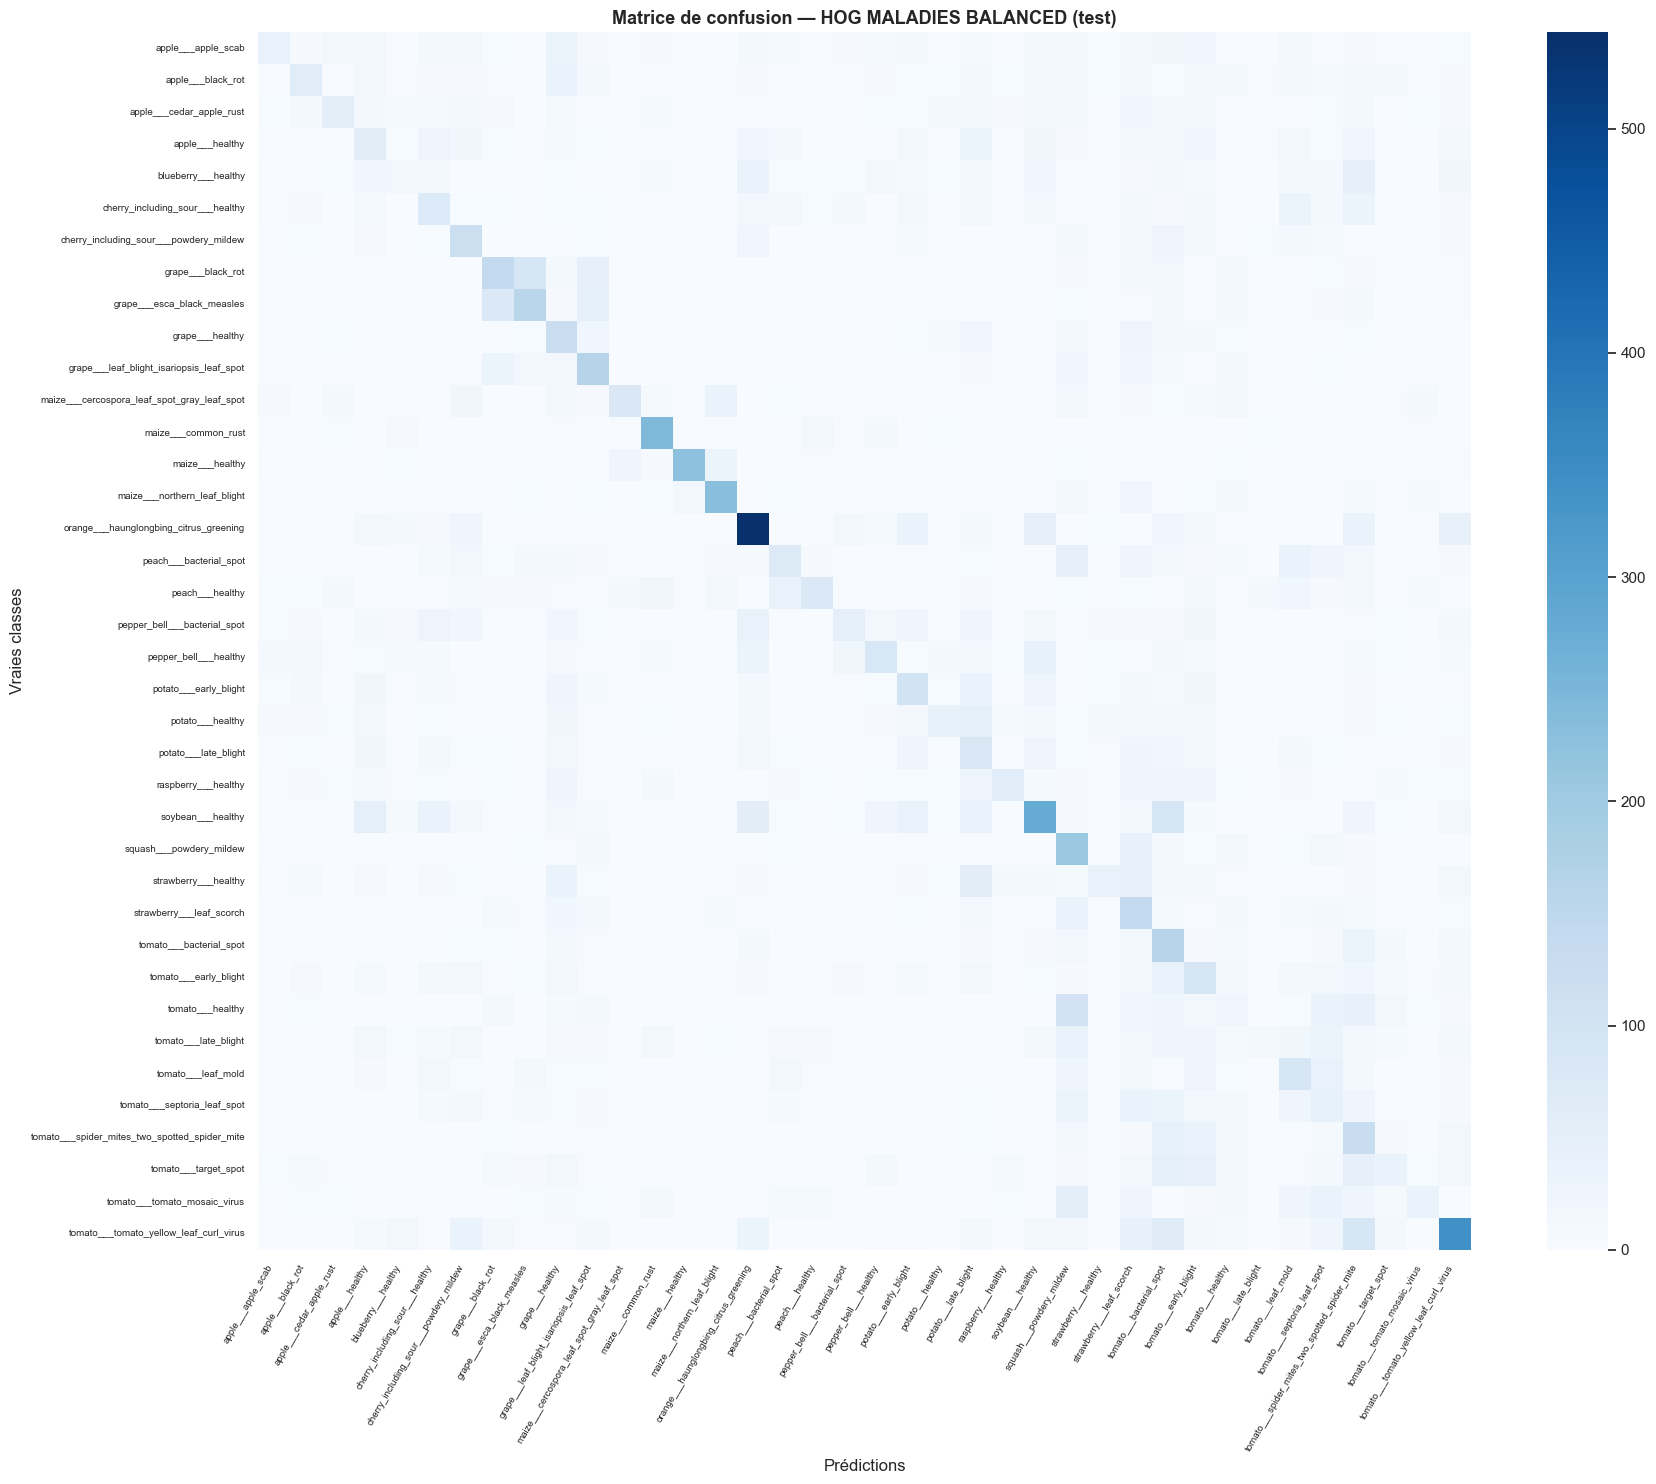

In [10]:
labels = sorted(pd.Series(y_test_true).unique())
cm = confusion_matrix(y_test_true, y_test_pred, labels=labels)

fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(cm, cmap="Blues", xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_title("Matrice de confusion — HOG MALADIES BALANCED (test)", fontsize=13, fontweight="bold")
ax.set_xlabel("Prédictions")
ax.set_ylabel("Vraies classes")
plt.xticks(rotation=60, ha="right", fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig("maladies_hog_balanced_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

Cell11 — Comparaison ablation

In [11]:
print("=" * 70)
print("COMPARAISON — ÉTUDE D'ABLATION MALADIES")
print("=" * 70)

test_row = df_metrics[df_metrics["split"] == "test"].iloc[0]
hog_acc = test_row["accuracy"]
hog_f1m = test_row["f1_macro"]
hog_f1w = test_row["f1_weighted"]

rows = [{"notebook": "NB07", "méthode": "HOG + balanced",
         "accuracy_test": hog_acc, "f1_macro_test": hog_f1m, "f1_weighted_test": hog_f1w}]

if REF_NB06_ACC is not None:
    rows.insert(0, {"notebook": "NB06", "méthode": "Pixels bruts + balanced",
                     "accuracy_test": REF_NB06_ACC, "f1_macro_test": REF_NB06_F1M, "f1_weighted_test": REF_NB06_F1W})
if REF_NB06BIS_ACC is not None:
    rows.insert(0, {"notebook": "NB06bis", "méthode": "Pixels bruts + no-balanced",
                     "accuracy_test": REF_NB06BIS_ACC, "f1_macro_test": REF_NB06BIS_F1M, "f1_weighted_test": REF_NB06BIS_F1W})

df_compare = pd.DataFrame(rows)
display(df_compare.round(4))

COMPARAISON — ÉTUDE D'ABLATION MALADIES


,notebook,méthode,accuracy_test,f1_macro_test,f1_weighted_test
0,NB07,HOG + balanced,0.3148,0.2878,0.3083


Cell12 — Sauvegarde

In [12]:
import json
import joblib
from pathlib import Path
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 60)
print("SAUVEGARDE DES OUTPUTS — HOG MALADIES (BALANCED)")
print("=" * 60)

required_vars = [
    "df_metrics",
    "y_val_true", "y_val_pred",
    "y_test_true", "y_test_pred",
    "clf", "scaler",
    "cm", "labels",
    "OUT_DIR"
]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise NameError(
        "Variables manquantes avant sauvegarde : "
        + ", ".join(missing)
        + ". Lance d'abord toutes les cellules précédentes."
    )

OUT_DIR = Path(OUT_DIR)
OUT_DIR.mkdir(parents=True, exist_ok=True)

PREFIX = "maladies_hog_balanced"

# ---------------------------------------------------------
# 1. Métriques finales
# ---------------------------------------------------------
df_metrics.to_csv(
    OUT_DIR / f"{PREFIX}_metrics_finales.csv",
    index=False,
    encoding="utf-8-sig"
)

# ---------------------------------------------------------
# 2. Tableau de comparaison (si disponible)
# ---------------------------------------------------------
if "df_compare" in globals():
    df_compare.to_csv(
        OUT_DIR / f"{PREFIX}_comparaison.csv",
        index=False,
        encoding="utf-8-sig"
    )

# ---------------------------------------------------------
# 3. Classification reports JSON
# ---------------------------------------------------------
report_val = classification_report(
    y_val_true, y_val_pred, output_dict=True, zero_division=0
)
report_test = classification_report(
    y_test_true, y_test_pred, output_dict=True, zero_division=0
)

with open(OUT_DIR / f"{PREFIX}_report_val.json", "w", encoding="utf-8") as f:
    json.dump(report_val, f, indent=2, ensure_ascii=False)

with open(OUT_DIR / f"{PREFIX}_report_test.json", "w", encoding="utf-8") as f:
    json.dump(report_test, f, indent=2, ensure_ascii=False)

# ---------------------------------------------------------
# 4. Prédictions test
# ---------------------------------------------------------
pd.DataFrame({
    "y_true": y_test_true,
    "y_pred": y_test_pred
}).to_csv(
    OUT_DIR / f"{PREFIX}_test_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

# ---------------------------------------------------------
# 5. Modèle + scaler
# ---------------------------------------------------------
joblib.dump(clf, OUT_DIR / f"{PREFIX}_model.joblib")
joblib.dump(scaler, OUT_DIR / f"{PREFIX}_scaler.joblib")

# ---------------------------------------------------------
# 6. Matrice de confusion — CSV
# ---------------------------------------------------------
cm_df = pd.DataFrame(cm, index=labels, columns=labels)
cm_df.to_csv(
    OUT_DIR / f"{PREFIX}_confusion_matrix_test.csv",
    encoding="utf-8-sig"
)

# ---------------------------------------------------------
# 7. Matrice de confusion — PNG
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    ax=ax
)
ax.set_title(
    "Matrice de confusion — HOG MALADIES BALANCED (test)",
    fontsize=13,
    fontweight="bold"
)
ax.set_xlabel("Prédictions")
ax.set_ylabel("Vraies classes")
plt.xticks(rotation=60, ha="right", fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig(
    OUT_DIR / f"{PREFIX}_confusion_matrix_test.png",
    dpi=150,
    bbox_inches="tight"
)
plt.close()

# ---------------------------------------------------------
# 8. Log final
# ---------------------------------------------------------
print("✅ Fichiers sauvegardés dans :", OUT_DIR)
for f in sorted(OUT_DIR.glob(f"{PREFIX}*")):
    print(" -", f.name)

SAUVEGARDE DES OUTPUTS — HOG MALADIES (BALANCED)
✅ Fichiers sauvegardés dans : C:\Users\Bronislaw\DS\Arena\MALADIES\new_ml_outputs_hog_balanced
 - maladies_hog_balanced_comparaison.csv
 - maladies_hog_balanced_confusion_matrix_test.csv
 - maladies_hog_balanced_confusion_matrix_test.png
 - maladies_hog_balanced_metrics_finales.csv
 - maladies_hog_balanced_model.joblib
 - maladies_hog_balanced_report_test.json
 - maladies_hog_balanced_report_val.json
 - maladies_hog_balanced_scaler.joblib
 - maladies_hog_balanced_test_predictions.csv


Cell13 — Synthèse

In [14]:
print("=" * 60)
print("SYNTHÈSE — HOG MALADIES")
print("=" * 60)

required_vars = ["df_metrics", "OUT_DIR", "PREFIX"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise NameError(
        "Variables manquantes avant synthèse : "
        + ", ".join(missing)
        + ". Lance d'abord les cellules d'évaluation et de sauvegarde."
    )

if not (df_metrics["split"] == "validation").any():
    raise ValueError("Aucun résultat 'validation' trouvé dans df_metrics.")
if not (df_metrics["split"] == "test").any():
    raise ValueError("Aucun résultat 'test' trouvé dans df_metrics.")

val_row  = df_metrics[df_metrics["split"] == "validation"].iloc[0]
test_row = df_metrics[df_metrics["split"] == "test"].iloc[0]

acc_val  = val_row["accuracy"]
f1m_val  = val_row["f1_macro"]
f1w_val  = val_row["f1_weighted"]

acc_test = test_row["accuracy"]
f1m_test = test_row["f1_macro"]
f1w_test = test_row["f1_weighted"]

# ---------------------------------------------------------
# 1. Stabilité validation / test
# ---------------------------------------------------------
gap_acc = abs(acc_val - acc_test)

if gap_acc < 0.02:
    stability_msg = (
        "Les performances validation/test sont très proches, "
        "ce qui suggère une bonne stabilité de généralisation."
    )
elif gap_acc < 0.05:
    stability_msg = (
        "Les performances validation/test restent relativement proches, "
        "avec une variation compatible avec une généralisation correcte."
    )
else:
    stability_msg = (
        "L'écart validation/test est notable, "
        "ce qui peut suggérer une sensibilité du modèle au split "
        "ou une généralisation moins stable."
    )

# ---------------------------------------------------------
# 2. Déséquilibre des classes
# ---------------------------------------------------------
gap_f1 = f1w_test - f1m_test

if gap_f1 < 0.03:
    balance_msg = (
        "L'écart entre F1-macro et F1-weighted reste faible, "
        "ce qui suggère une performance relativement homogène entre classes."
    )
elif gap_f1 < 0.08:
    balance_msg = (
        "Le F1-weighted est supérieur au F1-macro, "
        "ce qui indique un léger avantage du modèle sur les classes majoritaires."
    )
else:
    balance_msg = (
        "L'écart marqué entre F1-macro et F1-weighted indique que le modèle "
        "reste plus performant sur les classes majoritaires que sur les classes minoritaires."
    )

# ---------------------------------------------------------
# 3. Texte dépendant de la version
# ---------------------------------------------------------
if "no_balanced" in PREFIX:
    titre_modele = "HOG MALADIES (NO-BALANCED)"
    conclusion_modele = (
        "Ce notebook utilise des descripteurs HOG sans rééquilibrage explicite des classes. "
        "Il permet de mesurer l'effet du descripteur HOG seul dans l'étude d'ablation."
    )
elif "balanced" in PREFIX:
    titre_modele = "HOG MALADIES (BALANCED)"
    conclusion_modele = (
        "Ce notebook combine descripteurs HOG et rééquilibrage explicite des classes. "
        "Il permet d'évaluer l'apport conjoint de ces deux techniques dans l'étude d'ablation."
    )
else:
    titre_modele = "HOG MALADIES"
    conclusion_modele = (
        "Ce notebook repose sur une représentation HOG pour la tâche MALADIES."
    )

# ---------------------------------------------------------
# 4. Synthèse finale
# ---------------------------------------------------------
synthese = f"""
Le notebook {titre_modele} atteint les performances suivantes
sur les splits CLEAN :

• Accuracy validation : {acc_val:.4f}
• F1-macro validation : {f1m_val:.4f}
• F1-weighted validation : {f1w_val:.4f}

• Accuracy test : {acc_test:.4f}
• F1-macro test : {f1m_test:.4f}
• F1-weighted test : {f1w_test:.4f}

Interprétation :
{stability_msg}
{balance_msg}

Conclusion :
{conclusion_modele}
"""

print(synthese)

# ---------------------------------------------------------
# 5. Sauvegarde
# ---------------------------------------------------------
OUT_DIR = Path(OUT_DIR)
OUT_DIR.mkdir(parents=True, exist_ok=True)

with open(OUT_DIR / f"{PREFIX}_synthese.txt", "w", encoding="utf-8") as f:
    f.write(synthese)

print(f"\n✅ Synthèse sauvegardée : {OUT_DIR / f'{PREFIX}_synthese.txt'}")

SYNTHÈSE — HOG MALADIES

Le notebook HOG MALADIES (BALANCED) atteint les performances suivantes
sur les splits CLEAN :

• Accuracy validation : 0.3156
• F1-macro validation : 0.2899
• F1-weighted validation : 0.3107

• Accuracy test : 0.3148
• F1-macro test : 0.2878
• F1-weighted test : 0.3083

Interprétation :
Les performances validation/test sont très proches, ce qui suggère une bonne stabilité de généralisation.
L'écart entre F1-macro et F1-weighted reste faible, ce qui suggère une performance relativement homogène entre classes.

Conclusion :
Ce notebook combine descripteurs HOG et rééquilibrage explicite des classes. Il permet d'évaluer l'apport conjoint de ces deux techniques dans l'étude d'ablation.


✅ Synthèse sauvegardée : C:\Users\Bronislaw\DS\Arena\MALADIES\new_ml_outputs_hog_balanced\maladies_hog_balanced_synthese.txt


Komórka generujaca profesjonalne wykresy:

Accuracy dla wszystkich 6 notebooków
F1-macro dla wszystkich 6 notebooków

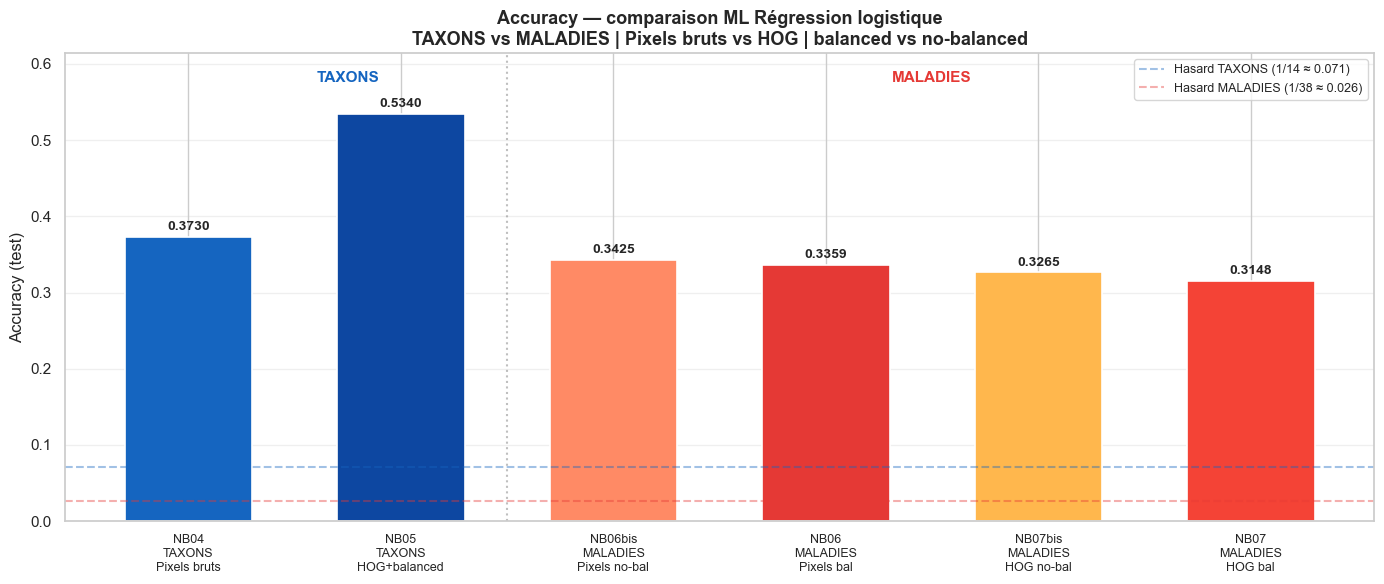

✅ Figure sauvegardée : ml_comparaison_accuracy.png


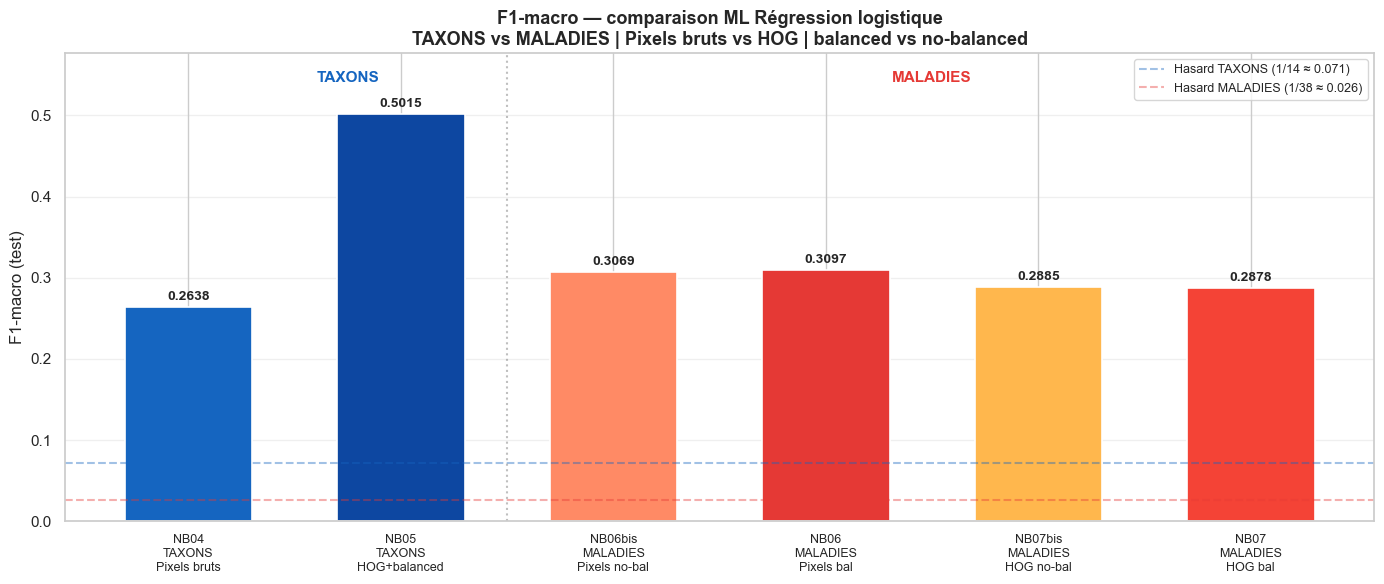

✅ Figure sauvegardée : ml_comparaison_f1_macro.png


In [17]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# DANE — wpisz tutaj swoje wyniki
# ============================================================

# --- TAXONS ---
NB04_ACC = 0.3730     # Pixels bruts, no-balanced
NB04_F1M = 0.2638

NB05_ACC = 0.5340     # HOG, balanced
NB05_F1M = 0.5015

# --- MALADIES ---
NB06_ACC = 0.3359     # Pixels bruts, balanced
NB06_F1M = 0.3097

NB06BIS_ACC = 0.3425  # Pixels bruts, no-balanced
NB06BIS_F1M = 0.3069

NB07_ACC = 0.3148     # HOG, balanced
NB07_F1M = 0.2878

NB07BIS_ACC = 0.3265  # HOG, no-balanced
NB07BIS_F1M = 0.2885

# ============================================================
# STRUKTURA DANYCH
# ============================================================

labels = [
    "NB04\nTAXONS\nPixels bruts",
    "NB05\nTAXONS\nHOG+balanced",
    "NB06bis\nMALADIES\nPixels no-bal",
    "NB06\nMALADIES\nPixels bal",
    "NB07bis\nMALADIES\nHOG no-bal",
    "NB07\nMALADIES\nHOG bal"
]

accuracy_values = [
    NB04_ACC,
    NB05_ACC,
    NB06BIS_ACC,
    NB06_ACC,
    NB07BIS_ACC,
    NB07_ACC
]

f1_macro_values = [
    NB04_F1M,
    NB05_F1M,
    NB06BIS_F1M,
    NB06_F1M,
    NB07BIS_F1M,
    NB07_F1M
]

# Couleurs : bleu = TAXONS, rouge/orange = MALADIES
# Foncé = balanced, clair = no-balanced
colors = [
    "#1565C0",   # NB04 TAXONS pixels (no-bal)
    "#0D47A1",   # NB05 TAXONS HOG (bal)
    "#FF8A65",   # NB06bis MALADIES pixels (no-bal)
    "#E53935",   # NB06 MALADIES pixels (bal)
    "#FFB74D",   # NB07bis MALADIES HOG (no-bal)
    "#F44336",   # NB07 MALADIES HOG (bal)
]

# ============================================================
# FIGURE 1 — ACCURACY
# ============================================================

x = np.arange(len(labels))
width = 0.6

fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.bar(x, accuracy_values, width, color=colors, edgecolor="white", linewidth=1.2)

# Valeurs au-dessus des barres
for bar, val in zip(bars, accuracy_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{val:.4f}",
        ha="center", va="bottom",
        fontsize=10, fontweight="bold"
    )

# Ligne horizontale : hasard TAXONS (1/14)
ax.axhline(y=1/14, color="#1565C0", linestyle="--", alpha=0.4, label="Hasard TAXONS (1/14 ≈ 0.071)")

# Ligne horizontale : hasard MALADIES (1/38)
ax.axhline(y=1/38, color="#E53935", linestyle="--", alpha=0.4, label="Hasard MALADIES (1/38 ≈ 0.026)")

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("Accuracy (test)", fontsize=12)
ax.set_title(
    "Accuracy — comparaison ML Régression logistique\n"
    "TAXONS vs MALADIES | Pixels bruts vs HOG | balanced vs no-balanced",
    fontsize=13, fontweight="bold"
)
ax.set_ylim(0, max(accuracy_values) * 1.15)
ax.legend(loc="upper right", fontsize=9)
ax.grid(axis="y", alpha=0.3)

# Séparateur visuel TAXONS / MALADIES
ax.axvline(x=1.5, color="gray", linestyle=":", alpha=0.5)
ax.text(0.75, max(accuracy_values) * 1.08, "TAXONS", ha="center", fontsize=11, color="#1565C0", fontweight="bold")
ax.text(3.5, max(accuracy_values) * 1.08, "MALADIES", ha="center", fontsize=11, color="#E53935", fontweight="bold")

plt.tight_layout()
plt.savefig("ml_comparaison_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ Figure sauvegardée : ml_comparaison_accuracy.png")

# ============================================================
# FIGURE 2 — F1-MACRO
# ============================================================

fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.bar(x, f1_macro_values, width, color=colors, edgecolor="white", linewidth=1.2)

for bar, val in zip(bars, f1_macro_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{val:.4f}",
        ha="center", va="bottom",
        fontsize=10, fontweight="bold"
    )

ax.axhline(y=1/14, color="#1565C0", linestyle="--", alpha=0.4, label="Hasard TAXONS (1/14 ≈ 0.071)")
ax.axhline(y=1/38, color="#E53935", linestyle="--", alpha=0.4, label="Hasard MALADIES (1/38 ≈ 0.026)")

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("F1-macro (test)", fontsize=12)
ax.set_title(
    "F1-macro — comparaison ML Régression logistique\n"
    "TAXONS vs MALADIES | Pixels bruts vs HOG | balanced vs no-balanced",
    fontsize=13, fontweight="bold"
)
ax.set_ylim(0, max(f1_macro_values) * 1.15)
ax.legend(loc="upper right", fontsize=9)
ax.grid(axis="y", alpha=0.3)

ax.axvline(x=1.5, color="gray", linestyle=":", alpha=0.5)
ax.text(0.75, max(f1_macro_values) * 1.08, "TAXONS", ha="center", fontsize=11, color="#1565C0", fontweight="bold")
ax.text(3.5, max(f1_macro_values) * 1.08, "MALADIES", ha="center", fontsize=11, color="#E53935", fontweight="bold")

plt.tight_layout()
plt.savefig("ml_comparaison_f1_macro.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ Figure sauvegardée : ml_comparaison_f1_macro.png")

Komórka — Matrice de confusion NB07 (orange-rouge)

MATRICE DE CONFUSION — HOG MALADIES BALANCED (test)
Dimensions de la matrice : (38, 38)
Nombre de classes        : 38


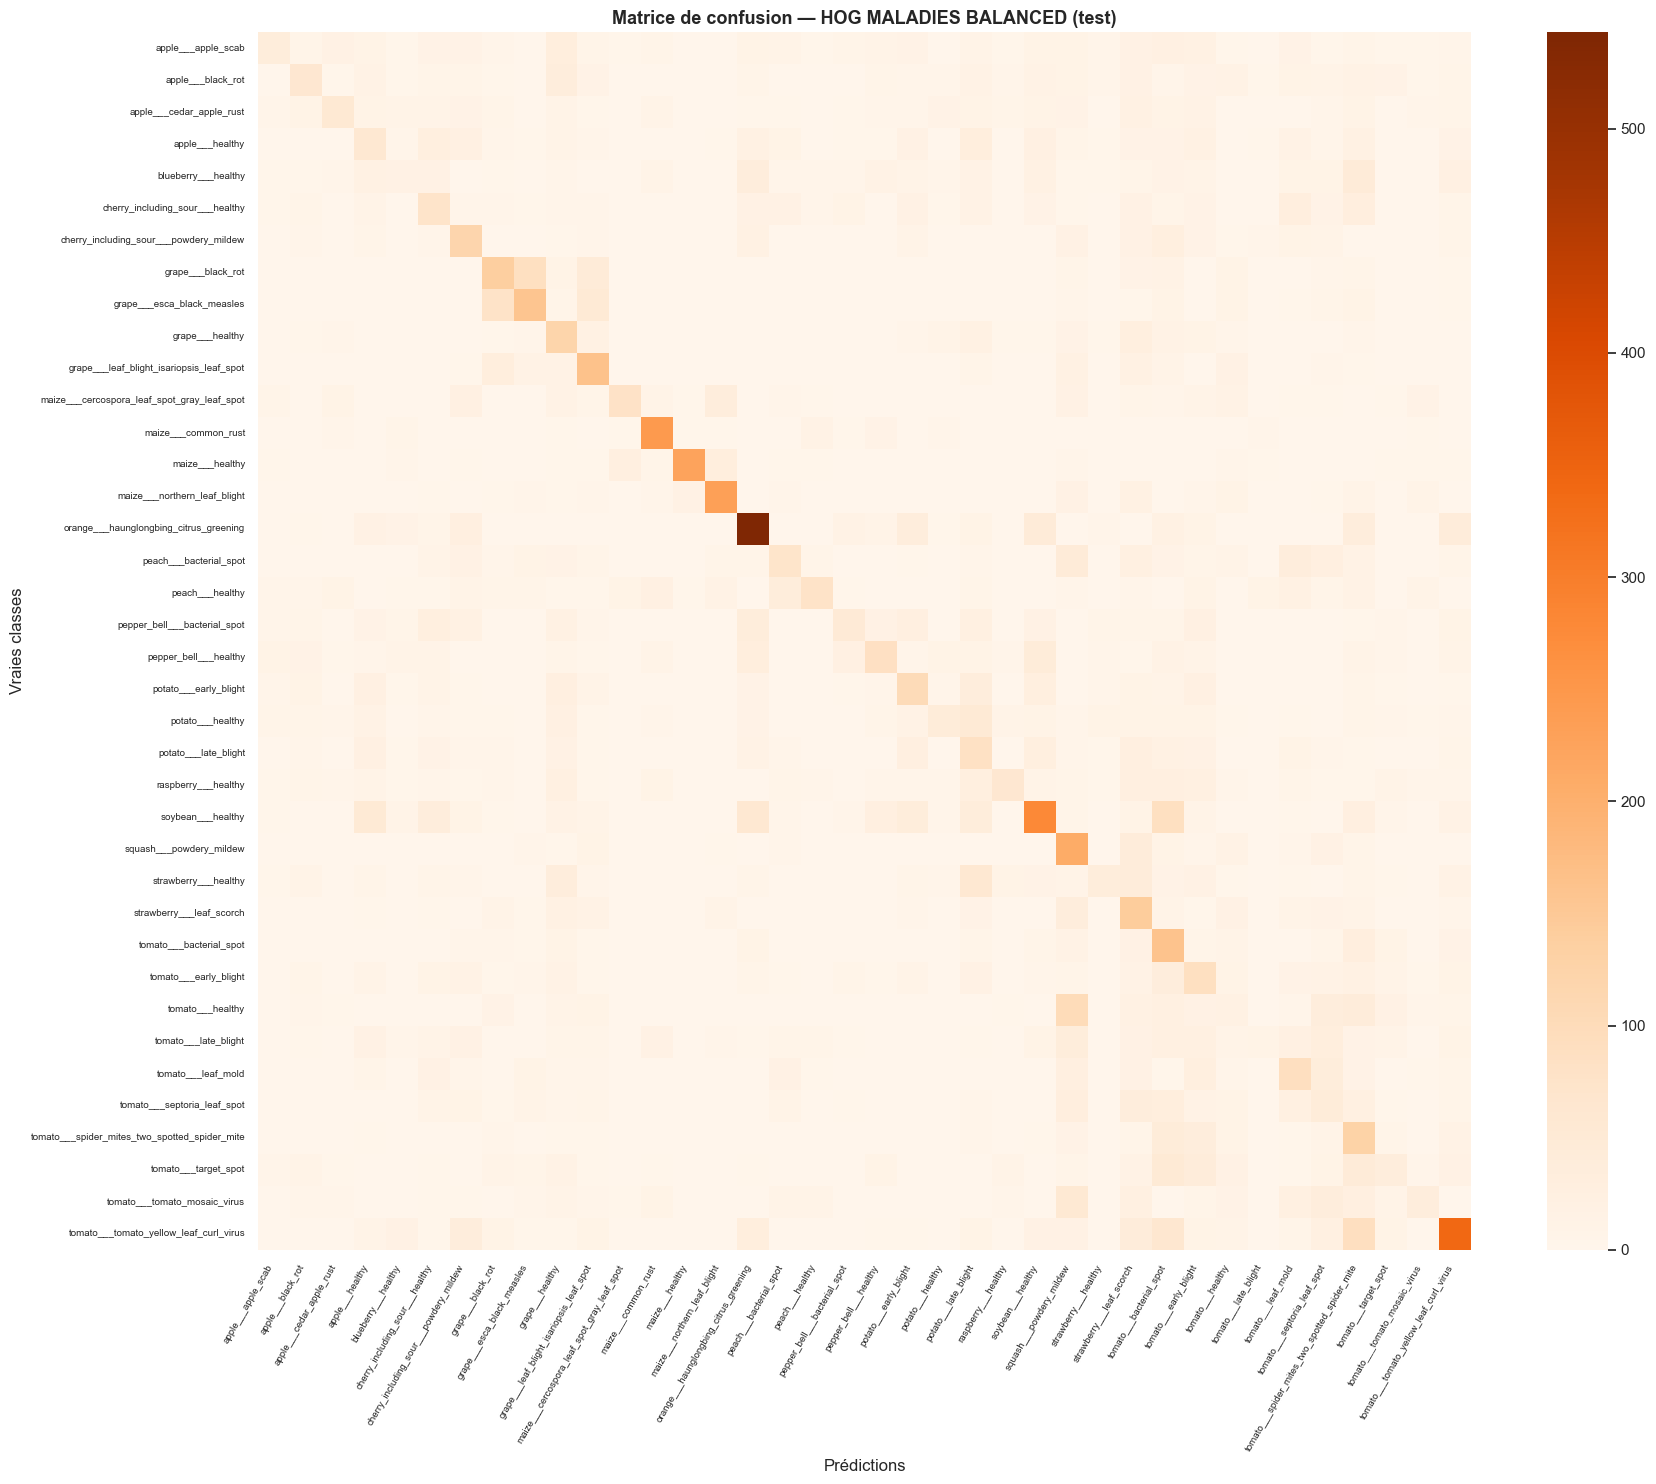


✅ Figure sauvegardée : maladies_hog_balanced_confusion_matrix_test.png


In [20]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("=" * 60)
print("MATRICE DE CONFUSION — HOG MALADIES BALANCED (test)")
print("=" * 60)

required_vars = ["y_test_true", "y_test_pred"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise NameError(
        "Variables manquantes : "
        + ", ".join(missing)
        + ". Lance d'abord la cellule d'évaluation test."
    )

labels = sorted(pd.Series(y_test_true).unique())
cm = confusion_matrix(y_test_true, y_test_pred, labels=labels)

print("Dimensions de la matrice :", cm.shape)
print("Nombre de classes        :", len(labels))

# Palette orange-rouge personnalisée
from matplotlib.colors import LinearSegmentedColormap

colors_list = [
    "#FFFFFF",   # blanc (zéro)
    "#FFF3E0",   # orange très pâle
    "#FFE0B2",   # orange pâle
    "#FFCC80",   # orange clair
    "#FFB74D",   # orange
    "#FF9800",   # orange vif
    "#F57C00",   # orange foncé
    "#E65100",   # orange-rouge
    "#D84315",   # rouge-orange
    "#BF360C",   # rouge foncé
    "#B71C1C",   # rouge très foncé
]

cmap_orange_rouge = LinearSegmentedColormap.from_list(
    "orange_rouge", colors_list, N=256
)

fig, ax = plt.subplots(figsize=(18, 15))

sns.heatmap(
    cm,
    cmap="Oranges",
    xticklabels=labels,
    yticklabels=labels,
    ax=ax
)

ax.set_title(
    "Matrice de confusion — HOG MALADIES BALANCED (test)",
    fontsize=13,
    fontweight="bold"
)
ax.set_xlabel("Prédictions")
ax.set_ylabel("Vraies classes")
plt.xticks(rotation=60, ha="right", fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()

plt.savefig(
    "maladies_hog_balanced_confusion_matrix_test.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("\n✅ Figure sauvegardée : maladies_hog_balanced_confusion_matrix_test.png")

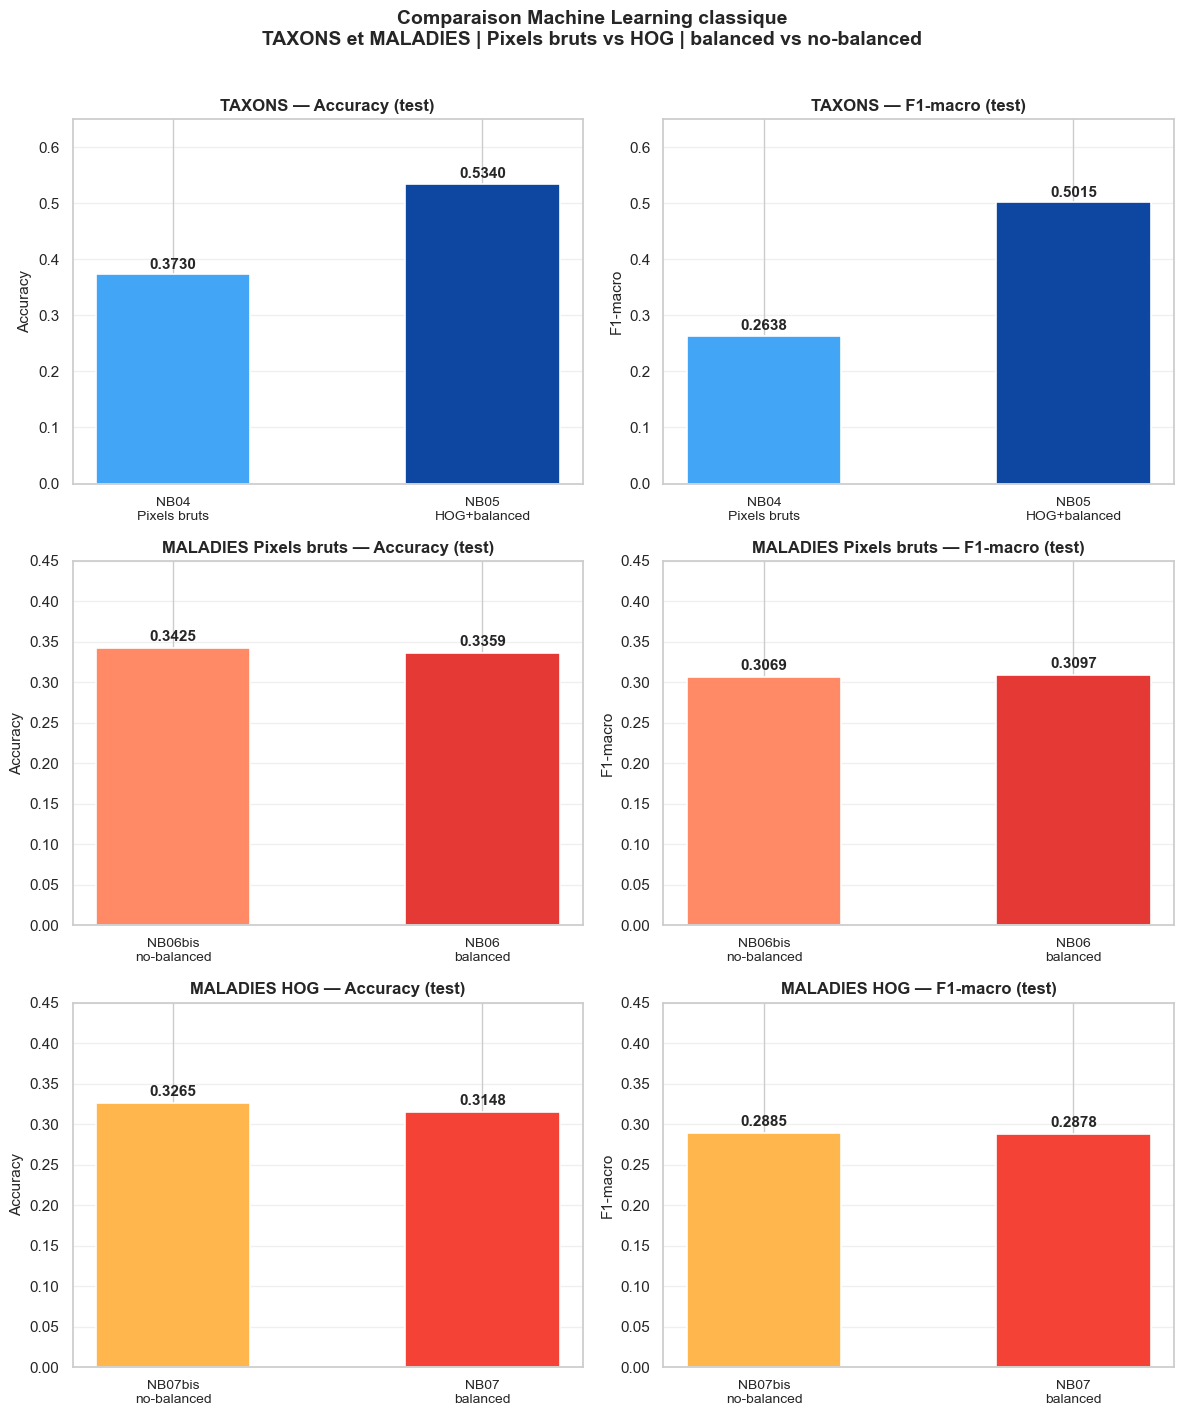

Figure sauvegardee : ml_6_sous_graphiques.png


In [22]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# DANE
# ============================================================

# TAXONS
taxons_labels = ["NB04\nPixels bruts", "NB05\nHOG+balanced"]
taxons_acc = [0.3730, 0.5340]
taxons_f1m = [0.2638, 0.5015]
taxons_colors = ["#42A5F5", "#0D47A1"]

# MALADIES baseline
mal_base_labels = ["NB06bis\nno-balanced", "NB06\nbalanced"]
mal_base_acc = [0.3425, 0.3359]
mal_base_f1m = [0.3069, 0.3097]
mal_base_colors = ["#FF8A65", "#E53935"]

# MALADIES HOG
mal_hog_labels = ["NB07bis\nno-balanced", "NB07\nbalanced"]
mal_hog_acc = [0.3265, 0.3148]
mal_hog_f1m = [0.2885, 0.2878]
mal_hog_colors = ["#FFB74D", "#F44336"]

# ============================================================
# FONCTION DE TRACÉ
# ============================================================

def plot_pair(ax, labels, values, colors, title, ylabel, ylim_max=None):
    x = np.arange(len(labels))
    bars = ax.bar(x, values, width=0.5, color=colors, edgecolor="white", linewidth=1.2)

    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{val:.4f}",
            ha="center", va="bottom",
            fontsize=11, fontweight="bold"
        )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)

    if ylim_max is not None:
        ax.set_ylim(0, ylim_max)
    else:
        ax.set_ylim(0, max(values) * 1.25)

# ============================================================
# FIGURE — 6 SOUS-GRAPHIQUES (3 lignes × 2 colonnes)
# ============================================================

fig, axes = plt.subplots(3, 2, figsize=(12, 14))

# Ligne 1 — TAXONS
plot_pair(
    axes[0, 0], taxons_labels, taxons_acc, taxons_colors,
    "TAXONS — Accuracy (test)", "Accuracy", ylim_max=0.65
)
plot_pair(
    axes[0, 1], taxons_labels, taxons_f1m, taxons_colors,
    "TAXONS — F1-macro (test)", "F1-macro", ylim_max=0.65
)

# Ligne 2 — MALADIES baseline
plot_pair(
    axes[1, 0], mal_base_labels, mal_base_acc, mal_base_colors,
    "MALADIES Pixels bruts — Accuracy (test)", "Accuracy", ylim_max=0.45
)
plot_pair(
    axes[1, 1], mal_base_labels, mal_base_f1m, mal_base_colors,
    "MALADIES Pixels bruts — F1-macro (test)", "F1-macro", ylim_max=0.45
)

# Ligne 3 — MALADIES HOG
plot_pair(
    axes[2, 0], mal_hog_labels, mal_hog_acc, mal_hog_colors,
    "MALADIES HOG — Accuracy (test)", "Accuracy", ylim_max=0.45
)
plot_pair(
    axes[2, 1], mal_hog_labels, mal_hog_f1m, mal_hog_colors,
    "MALADIES HOG — F1-macro (test)", "F1-macro", ylim_max=0.45
)
plt.suptitle(
    "Comparaison Machine Learning classique\n"
    "TAXONS et MALADIES | Pixels bruts vs HOG | balanced vs no-balanced",
    fontsize=14, fontweight="bold", y=1.01
)

plt.tight_layout()

output_path = "ml_6_sous_graphiques.png"
plt.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()

print("Figure sauvegardee :", output_path)

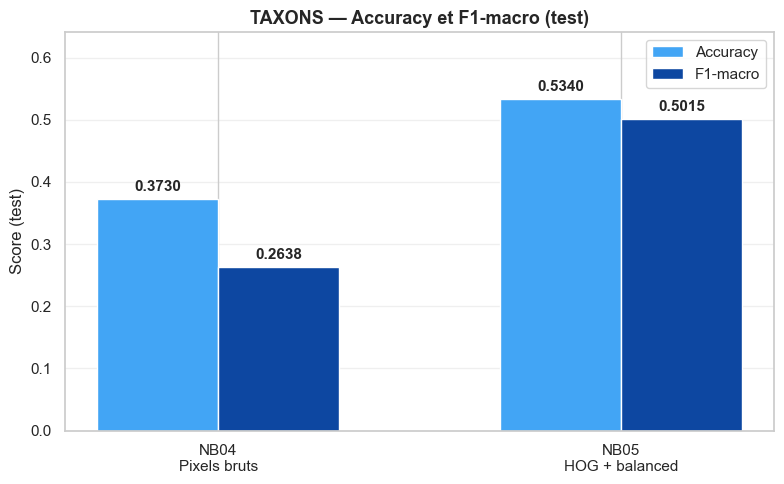

Figure sauvegardee : taxons_accuracy_f1macro.png


In [23]:
import matplotlib.pyplot as plt
import numpy as np

labels = ["NB04\nPixels bruts", "NB05\nHOG + balanced"]
acc_values = [0.3730, 0.5340]
f1m_values = [0.2638, 0.5015]

x = np.arange(len(labels))
width = 0.3

fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar(x - width/2, acc_values, width, label="Accuracy", color="#42A5F5", edgecolor="white")
bars2 = ax.bar(x + width/2, f1m_values, width, label="F1-macro", color="#0D47A1", edgecolor="white")

for bar, val in zip(bars1, acc_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
            f"{val:.4f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

for bar, val in zip(bars2, f1m_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
            f"{val:.4f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel("Score (test)", fontsize=12)
ax.set_title("TAXONS — Accuracy et F1-macro (test)", fontsize=13, fontweight="bold")
ax.set_ylim(0, max(acc_values + f1m_values) * 1.2)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("taxons_accuracy_f1macro.png", dpi=150, bbox_inches="tight")
plt.show()

print("Figure sauvegardee : taxons_accuracy_f1macro.png")

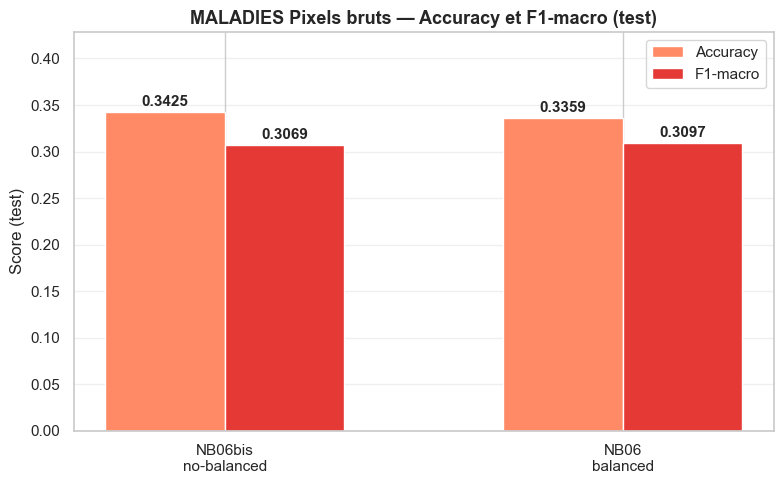

Figure sauvegardee : maladies_baseline_accuracy_f1macro.png


In [24]:
import matplotlib.pyplot as plt
import numpy as np

labels = ["NB06bis\nno-balanced", "NB06\nbalanced"]
acc_values = [0.3425, 0.3359]
f1m_values = [0.3069, 0.3097]

x = np.arange(len(labels))
width = 0.3

fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar(x - width/2, acc_values, width, label="Accuracy", color="#FF8A65", edgecolor="white")
bars2 = ax.bar(x + width/2, f1m_values, width, label="F1-macro", color="#E53935", edgecolor="white")

for bar, val in zip(bars1, acc_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{val:.4f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

for bar, val in zip(bars2, f1m_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{val:.4f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel("Score (test)", fontsize=12)
ax.set_title("MALADIES Pixels bruts — Accuracy et F1-macro (test)",
             fontsize=13, fontweight="bold")
ax.set_ylim(0, max(acc_values + f1m_values) * 1.25)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("maladies_baseline_accuracy_f1macro.png", dpi=150, bbox_inches="tight")
plt.show()

print("Figure sauvegardee : maladies_baseline_accuracy_f1macro.png")

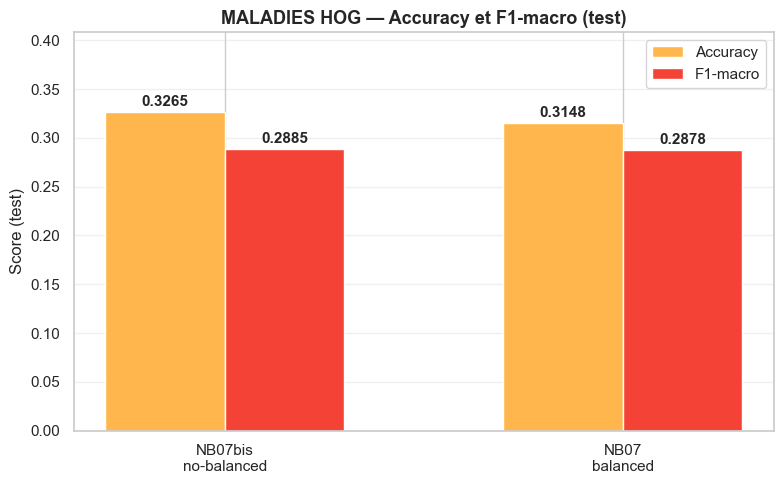

Figure sauvegardee : maladies_hog_accuracy_f1macro.png


In [25]:
import matplotlib.pyplot as plt
import numpy as np

labels = ["NB07bis\nno-balanced", "NB07\nbalanced"]
acc_values = [0.3265, 0.3148]
f1m_values = [0.2885, 0.2878]

x = np.arange(len(labels))
width = 0.3

fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar(x - width/2, acc_values, width, label="Accuracy", color="#FFB74D", edgecolor="white")
bars2 = ax.bar(x + width/2, f1m_values, width, label="F1-macro", color="#F44336", edgecolor="white")

for bar, val in zip(bars1, acc_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{val:.4f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

for bar, val in zip(bars2, f1m_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{val:.4f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel("Score (test)", fontsize=12)
ax.set_title("MALADIES HOG — Accuracy et F1-macro (test)",
             fontsize=13, fontweight="bold")
ax.set_ylim(0, max(acc_values + f1m_values) * 1.25)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("maladies_hog_accuracy_f1macro.png", dpi=150, bbox_inches="tight")
plt.show()

print("Figure sauvegardee : maladies_hog_accuracy_f1macro.png")

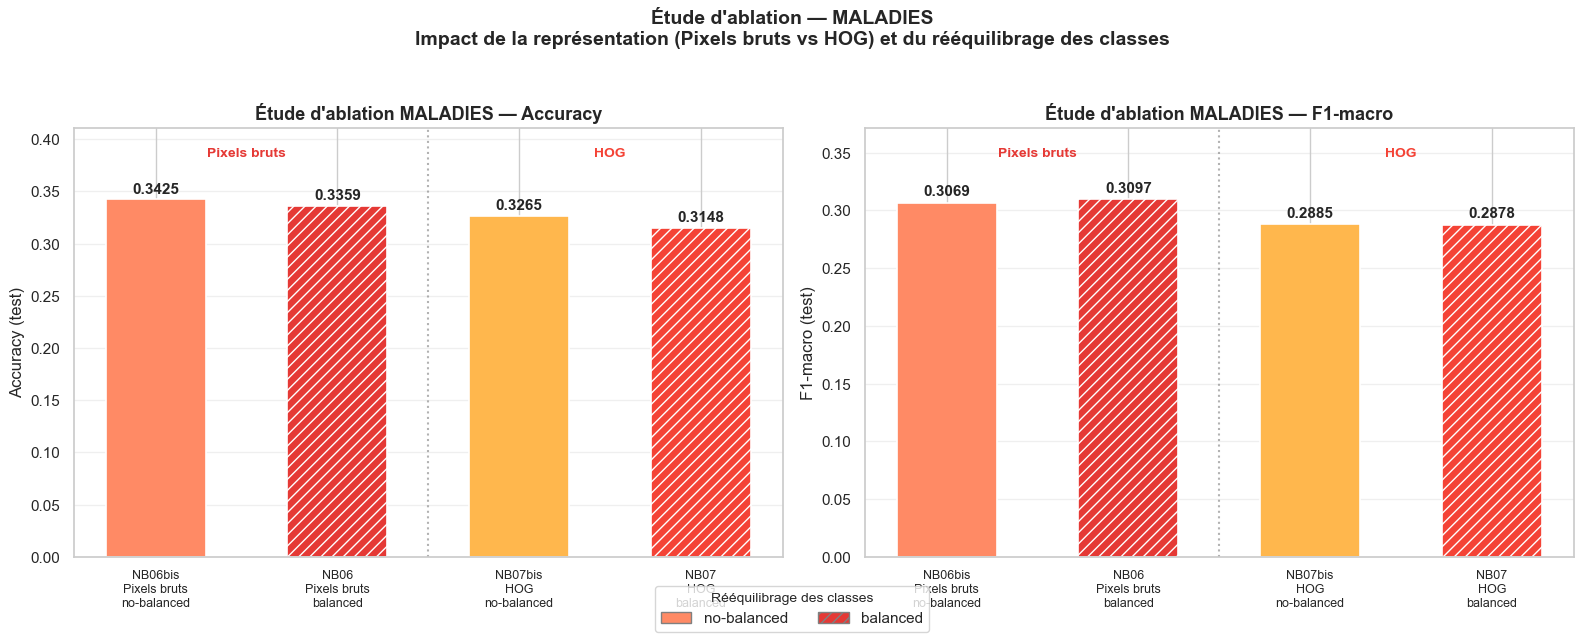

✅ Figure sauvegardée : ml_ablation_maladies.png


In [26]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# DANE — tylko MALADIES
# ============================================================

ablation_labels = [
    "NB06bis\nPixels bruts\nno-balanced",
    "NB06\nPixels bruts\nbalanced",
    "NB07bis\nHOG\nno-balanced",
    "NB07\nHOG\nbalanced"
]

ablation_acc = [0.3425, 0.3359, 0.3265, 0.3148]
ablation_f1m = [0.3069, 0.3097, 0.2885, 0.2878]

# Couleurs : clair = no-balanced, foncé = balanced
# Orange = pixels bruts, rouge = HOG
ablation_colors = [
    "#FF8A65",   # NB06bis pixels no-bal
    "#E53935",   # NB06 pixels bal
    "#FFB74D",   # NB07bis HOG no-bal
    "#F44336",   # NB07 HOG bal
]

# Motifs pour distinguer balanced / no-balanced
hatches = ["", "///", "", "///"]

# ============================================================
# FIGURE — ACCURACY
# ============================================================

x = np.arange(len(ablation_labels))
width = 0.55

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Accuracy ---
bars1 = ax1.bar(
    x, ablation_acc, width,
    color=ablation_colors,
    edgecolor="white",
    linewidth=1.2
)

for bar, val, hatch in zip(bars1, ablation_acc, hatches):
    bar.set_hatch(hatch)
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.003,
        f"{val:.4f}",
        ha="center", va="bottom",
        fontsize=11, fontweight="bold"
    )

ax1.set_xticks(x)
ax1.set_xticklabels(ablation_labels, fontsize=9)
ax1.set_ylabel("Accuracy (test)", fontsize=12)
ax1.set_title("Étude d'ablation MALADIES — Accuracy", fontsize=13, fontweight="bold")
ax1.set_ylim(0, max(ablation_acc) * 1.2)
ax1.grid(axis="y", alpha=0.3)

# Séparateur Pixels / HOG
ax1.axvline(x=1.5, color="gray", linestyle=":", alpha=0.6)
ax1.text(0.5, max(ablation_acc) * 1.12, "Pixels bruts", ha="center", fontsize=10, color="#E53935", fontweight="bold")
ax1.text(2.5, max(ablation_acc) * 1.12, "HOG", ha="center", fontsize=10, color="#F44336", fontweight="bold")

# --- F1-macro ---
bars2 = ax2.bar(
    x, ablation_f1m, width,
    color=ablation_colors,
    edgecolor="white",
    linewidth=1.2
)

for bar, val, hatch in zip(bars2, ablation_f1m, hatches):
    bar.set_hatch(hatch)
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.003,
        f"{val:.4f}",
        ha="center", va="bottom",
        fontsize=11, fontweight="bold"
    )

ax2.set_xticks(x)
ax2.set_xticklabels(ablation_labels, fontsize=9)
ax2.set_ylabel("F1-macro (test)", fontsize=12)
ax2.set_title("Étude d'ablation MALADIES — F1-macro", fontsize=13, fontweight="bold")
ax2.set_ylim(0, max(ablation_f1m) * 1.2)
ax2.grid(axis="y", alpha=0.3)

ax2.axvline(x=1.5, color="gray", linestyle=":", alpha=0.6)
ax2.text(0.5, max(ablation_f1m) * 1.12, "Pixels bruts", ha="center", fontsize=10, color="#E53935", fontweight="bold")
ax2.text(2.5, max(ablation_f1m) * 1.12, "HOG", ha="center", fontsize=10, color="#F44336", fontweight="bold")

# Légende commune
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#FF8A65", edgecolor="gray", label="no-balanced"),
    Patch(facecolor="#E53935", edgecolor="gray", hatch="///", label="balanced"),
]
fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=2,
    fontsize=11,
    frameon=True,
    title="Rééquilibrage des classes",
    title_fontsize=10,
    bbox_to_anchor=(0.5, -0.02)
)

plt.suptitle(
    "Étude d'ablation — MALADIES\n"
    "Impact de la représentation (Pixels bruts vs HOG) et du rééquilibrage des classes",
    fontsize=14, fontweight="bold", y=1.03
)

plt.tight_layout()
plt.savefig("ml_ablation_maladies.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ Figure sauvegardée : ml_ablation_maladies.png")

Accuracy train:

In [27]:
print("=" * 60)
print("ÉVALUATION — TRAIN")
print("=" * 60)

y_train_true, y_train_pred = predict_stream_hog(
    csv_path=TRAIN_CSV,
    split_name="train",
    scaler=scaler,
    clf=clf,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    base_dir=BASE_DIR,
    max_images=MAX_IMAGES_TRAIN,
    task="maladies"
)

metrics_train = compute_metrics(y_train_true, y_train_pred, "train")
df_metrics_train = pd.DataFrame([metrics_train])

display(df_metrics_train.round(4))

print("\nClassification report (train):")
print(classification_report(y_train_true, y_train_pred, zero_division=0))

ÉVALUATION — TRAIN

Streaming HOG train ...
  path_col   : chemin
  label_col  : maladie_label
  batch_size : 512
  img_size   : 64
✅ Fin streaming HOG train
   images valides : 67,339 | manquantes : 0 | erreurs HOG : 0


,split,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,train,0.3278,0.337,0.3115,0.3012,0.3214



Classification report (train):
                                               precision    recall  f1-score   support

                           apple___apple_scab       0.32      0.13      0.19      1795
                            apple___black_rot       0.29      0.15      0.20      1754
                     apple___cedar_apple_rust       0.38      0.16      0.23      1557
                              apple___healthy       0.20      0.17      0.18      1745
                          blueberry___healthy       0.23      0.10      0.14      1580
              cherry_including_sour___healthy       0.21      0.24      0.23      1597
       cherry_including_sour___powdery_mildew       0.30      0.43      0.35      1480
                            grape___black_rot       0.33      0.40      0.36      1668
                   grape___esca_black_measles       0.42      0.40      0.41      1672
                              grape___healthy       0.24      0.43      0.31      1516
     grape

To nie jest tak, że HOG "nie nadaje się do projektów Computer Vision". HOG to jeden z najsłynniejszych algorytmów w historii widzenia komputerowego!

Poprawka polega na tym:

HOG jest genialny do rozpoznawania kształtów (np. gatunków roślin), ale jest fatalny do rozpoznawania chorób, ponieważ choroby objawiają się głównie przez kolor i mikroteksturę, które HOG niszczy.

Il faut apporter une nuance très importante. La méthode HOG n'est pas mauvaise pour la vision par ordinateur en général, mais elle est inadaptée à la pathologie végétale (les maladies).

Le HOG travaille sur des images en niveaux de gris pour extraire la géométrie et les contours. C'est pourquoi il a très bien fonctionné sur notre tâche TAXONS : une feuille de maïs et une feuille de fraisier ont des formes très différentes, que le HOG capte parfaitement.

En revanche, sur la tâche MALADIES, une feuille saine et une feuille malade ont exactement la même forme. La maladie se manifeste par des décolorations (jaunissement, taches brunes). En convertissant l'image en niveaux de gris, le HOG détruit l'information colorimétrique qui est le symptôme principal de la maladie.

C'est ce qui explique nos résultats : le HOG améliore les scores sur les espèces (où la morphologie compte), mais dégrade les scores sur les maladies (où la couleur compte).